In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import topovelo as tpv
import matplotlib.pyplot as plt

In [2]:
FIG_DIR='./figures/thymus-ped'
MODEL_DIR = './checkpoints/thymus-ped'
DATA_DIR = ''
OUT_DIR = ''
DATA_NAME = 'thymus-ped'

In [3]:
adata = sc.read(os.path.join(DATA_DIR, f'{DATA_NAME}_pp.h5ad'))

In [4]:
DATASET = 'thymus-ped'
# GCN
vae = tpv.VAE(adata, 
              tmax=20, 
              dim_z=5, 
              device='cuda:0',
              graph_decoder=True,
              attention=False,
              reverse_gene_mode=False)
vae.train(adata,
          adata.obsp['spatial_graph'],
          "X_spatial",
          config={
              'learning_rate': 5e-3,
              'learning_rate_ode': 1e-4,
              'learning_rate_refine': 5e-3
          },
          plot=False,
          embed='spatial')
vae.save_model(os.path.join(MODEL_DIR, 'gcn'), 'encoder', 'decoder')
vae.save_anndata(adata, 'gcn', os.path.join(OUT_DIR, DATA_NAME))

vae = tpv.VAE(adata, 
              tmax=20, 
              dim_z=5, 
              device='cuda:0',
              graph_decoder=True,
              attention=True,
              reverse_gene_mode=False)
vae.train(adata,
          adata.obsp['spatial_graph'],
          "X_spatial",
          config={
              'learning_rate': 5e-3,
              'learning_rate_ode': 1e-3,
              'learning_rate_refine': 5e-3
          },
          plot=False,
          embed='spatial')
vae.save_model(os.path.join(MODEL_DIR, 'gat'), 'encoder', 'decoder')
vae.save_anndata(adata, 'gat', os.path.join(OUT_DIR, DATASET), file_name="adata_out.h5ad")

Estimating ODE parameters...


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Reinitialize the regular ODE parameters based on estimated global latent time.


  0%|          | 0/100 [00:00<?, ?it/s]

...

Reinitialize the regular ODE parameters based on estimated global latent time.


  0%|          | 0/100 [00:00<?, ?it/s]

*********               Creating a Graph Dataset              *********
*********                      Finished.                      *********
--------------------------- Train a TopoVelo ---------------------------
*********                 Creating optimizers                 *********
*********                      Finished.                      *********
*********                    Start training                   *********
*********                      Stage  1                       *********
*********       Stage 1: Early Stop Triggered at epoch 246.       *********
Summary: 
Train ELBO = 87.468
Test ELBO = 83.107
Total Time =   0 h :  1 m : 54 s

*********                      Stage  2                       *********


Calculating KNN:   0%|          | 0/2165 [00:00<?, ?it/s]

Stage 2: Early Stop Triggered at round 11.
Final: Train ELBO = 181.795,	Test ELBO = 187.893
*********              Finished. Total Time =   0 h :  3 m : 59 s             *********


In [5]:
adata.obs['tprior'] = -adata.obs['cma_v2'].to_numpy()

---   Plotting  Results   ---
Computing a spatial graph using KNN on spatial with k=50
computing neighbors
    finished (0:00:02) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/32 cores)


  0%|          | 0/2165 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'gcn_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'gcn_velocity_spatial', embedded velocity vectors (adata.obsm)


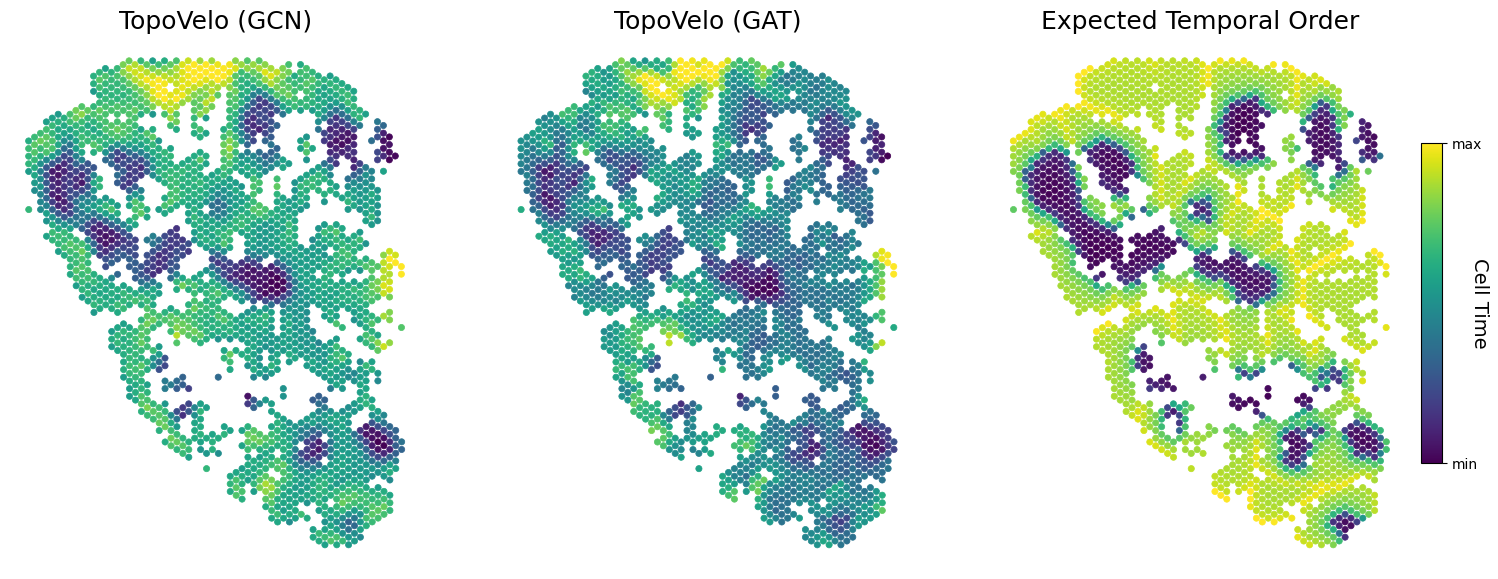

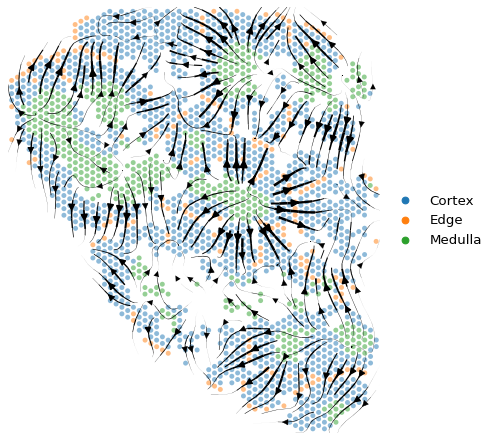

Recovering the original KNN graph from .uns
Computing a spatial graph using KNN on spatial with k=50
computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/32 cores)


  0%|          | 0/2165 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'gat_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'gat_velocity_spatial', embedded velocity vectors (adata.obsm)


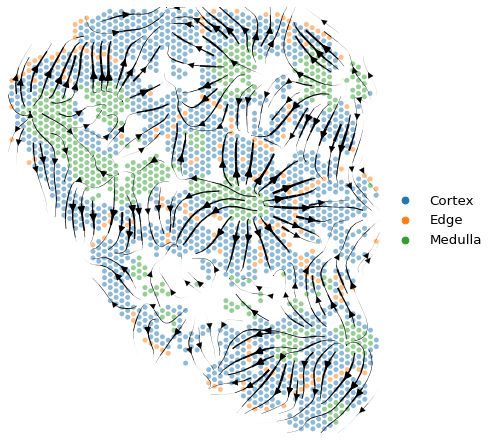

Recovering the original KNN graph from .uns


(None, None, None, None)

In [6]:
tpv.post_analysis(
    adata,
    'thymus-ped',
    ['TopoVelo (GCN)', 'TopoVelo (GAT)'],
    ['gcn', 'gat'],
    compute_metrics=False,
    plot_type=['time', 'cell velocity'],
    plot_basis='spatial',
)